In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_rel, wilcoxon


In [66]:
file = '/itf-fi-ml/shared/users/ziyuzh/svm/results/2019_df_oob.xlsx'
df = pd.read_excel(file, sheet_name='disease')

In [67]:
mapping = {
    'uniport_ppi_2019': 'ppi_emb',
    # 'ppi_2019_dw_40': 'ppi_emb',
    'uniport_bio': 'literature_emb',
    'uniport_seq': 'seq_emb'
}

df['para'] = df['para'].replace(mapping)

In [63]:
df_raw = pd.read_csv('/itf-fi-ml/shared/users/ziyuzh/svm/results/2019_fused_full/all_disease.csv')

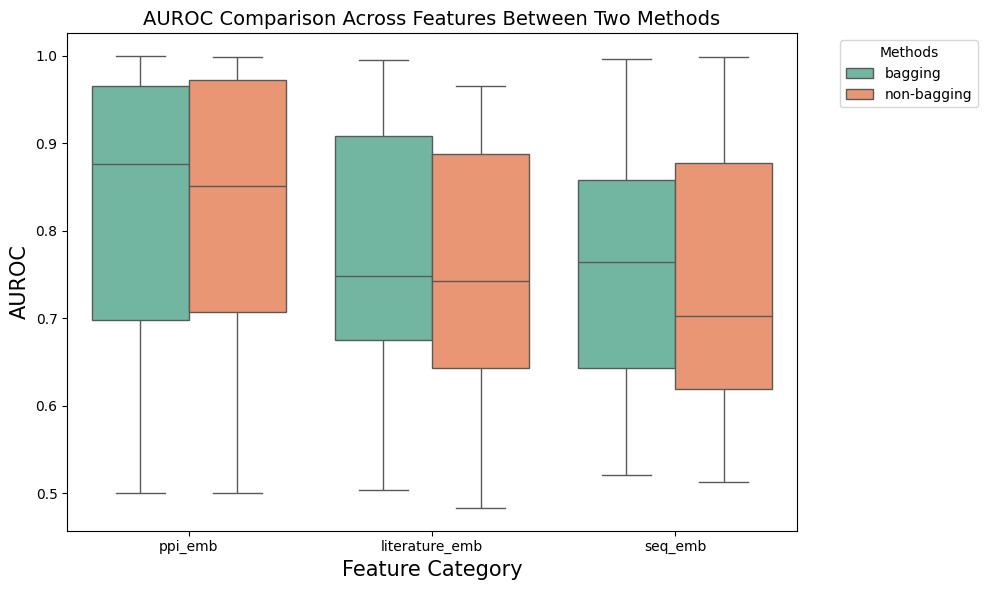

In [85]:
file2 = '/itf-fi-ml/shared/users/ziyuzh/svm/results/2019_fused.xlsx'
# file2 = '/itf-fi-ml/shared/users/ziyuzh/svm/results/2019_fused_remap.xlsx'

# df_raw = pd.read_excel(file2, sheet_name='disease')
df_raw = pd.read_csv('/itf-fi-ml/shared/users/ziyuzh/svm/results/2019_fused_full/all_disease.csv')

df = df[df['auroc']>0.5]
df_raw = df_raw[df_raw['auroc']>0.5]

# df_raw['auroc'] = df_raw['auroc'] - 0.02

if 'remap' in file2:
    mapping = {
        'uniport_ppi_2019': 'ppi_emb',
        'uniport_bio': 'literature_emb',
        'uniport_seq': 'seq_emb'
    }
else:
    mapping = {
        'ppi_2019': 'ppi_emb',
        'bioconcept': 'literature_emb',
        'uniport': 'seq_emb'
    }

df_raw['para'] = df_raw['para'].replace(mapping)
df_raw.loc[df_raw['para'] == 'literature_emb', 'auroc'] = df_raw.loc[df_raw['para'] == 'literature_emb', 'auroc'] - 0.02

# Define features of interest
features = ['ppi_emb', 'literature_emb', 'seq_emb']

df1 = df[df['para'].isin(features)].copy()
df2 = df_raw[df_raw['para'].isin(features)].copy()

df1['source'] = 'bagging'
df2['source'] = 'non-bagging'

intersection_disease = set(df1['disease'].tolist()) & set(df2['disease'].tolist())
df1 = df1[df1['disease'].isin(intersection_disease)]
df2 = df2[df2['disease'].isin(intersection_disease)]

# Combine them
filtered_df = pd.concat([df1, df2], ignore_index=True)

# Plot
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=filtered_df,
    x='para',       # feature category
    y='auroc',      # performance
    hue='source',   # compare datasets
    palette='Set2'
)

# Customize
plt.title('AUROC Comparison Across Features Between Two Methods', fontsize=14)
plt.xlabel('Feature Category', fontsize=15)
plt.ylabel('AUROC', fontsize=15)
plt.legend(title='Methods', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


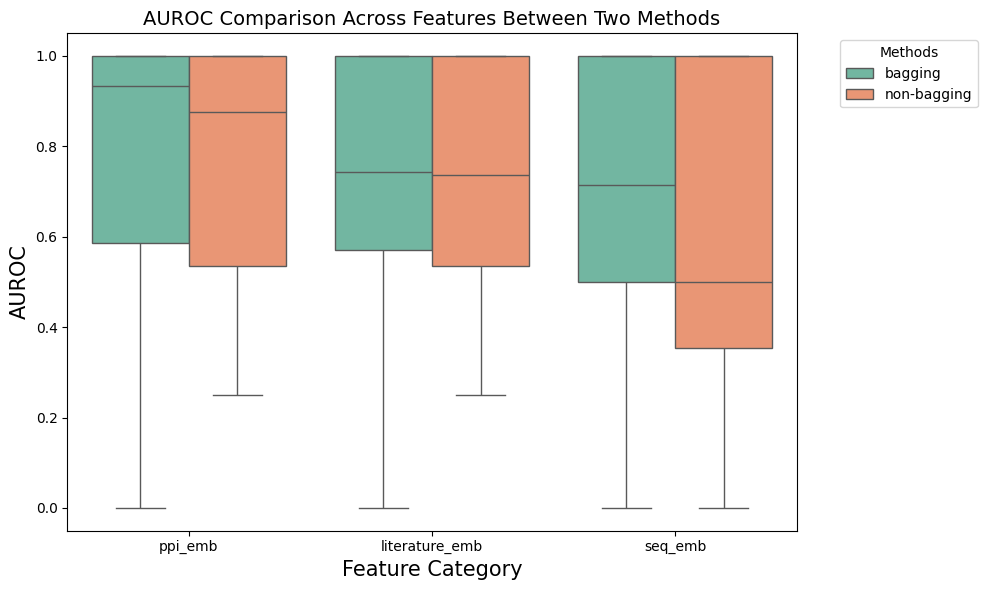

In [84]:
# Plot
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=filtered_df,
    x='para',       # feature category
    y='top_recall_30%',      # performance
    # y='top_recall_300',      # performance
    hue='source',   # compare datasets
    palette='Set2'
)

# Customize
plt.title('AUROC Comparison Across Features Between Two Methods', fontsize=14)
plt.xlabel('Feature Category', fontsize=15)
plt.ylabel('AUROC', fontsize=15)
plt.legend(title='Methods', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

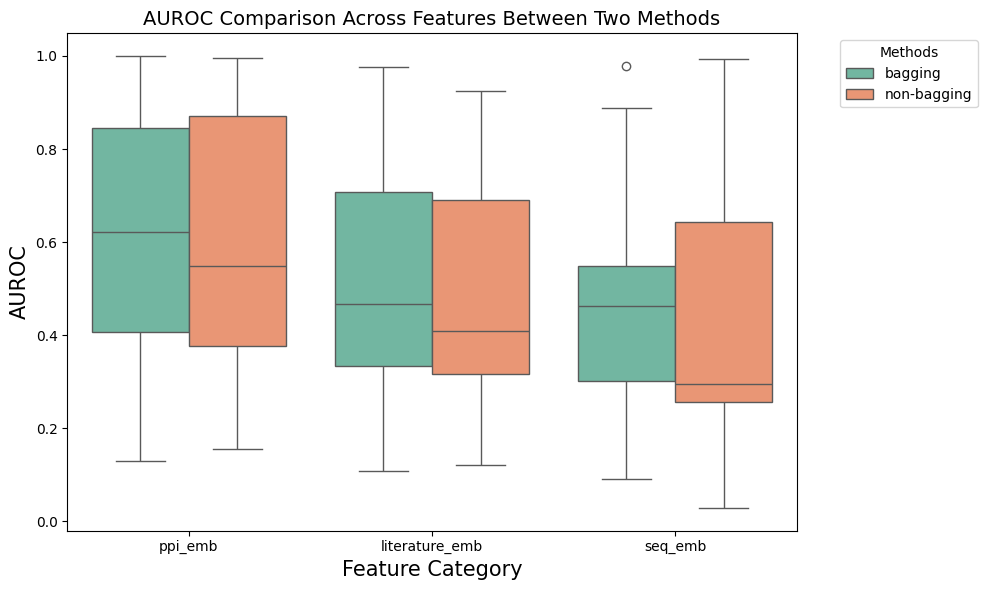

In [79]:
# Plot
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=filtered_df,
    x='para',       # feature category
    y='bedroc_30',      # performance
    hue='source',   # compare datasets
    palette='Set2'
)

# Customize
plt.title('AUROC Comparison Across Features Between Two Methods', fontsize=14)
plt.xlabel('Feature Category', fontsize=15)
plt.ylabel('AUROC', fontsize=15)
plt.legend(title='Methods', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [80]:
filtered_df

,method,para,top_recall_25,top_recall_300,top_recall_10%,top_recall_30%,auroc,rank_ratio,bedroc_1,bedroc_5,...,top_precision_30%,max_precision_30%,pm_0.5%,pm_1%,pm_5%,pm_10%,pm_15%,pm_20%,pm_25%,pm_30%
0,random_negative,ppi_emb,0.222000,0.556000,0.667000,0.889000,0.873000,0.1270,0.343000,0.506000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,random_negative,literature_emb,0.111000,0.333000,0.444000,0.667000,0.743000,0.2570,0.190000,0.317000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,random_negative,seq_emb,0.000000,0.222000,0.444000,0.889000,0.829000,0.1720,0.064000,0.266000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,random_negative,ppi_emb,0.000000,0.000000,0.000000,1.000000,0.884000,0.1160,0.000000,0.024000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,random_negative,literature_emb,0.000000,0.000000,0.000000,0.000000,0.588000,0.4120,0.000000,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
184,random_negative,ppi_emb,0.666667,0.666667,1.000000,1.000000,0.968137,0.0320,0.603402,0.669470,...,0.000828,0.000828,0.992851,0.985563,0.930464,0.909317,0.869781,0.833483,0.800146,0.769373
185,random_negative,seq_emb,0.333333,0.666667,0.666667,1.000000,0.923860,0.0763,0.462040,0.612633,...,0.000828,0.000828,0.985563,0.985563,0.930464,0.869781,0.816529,0.769348,0.800146,0.769373
186,random_negative,literature_emb,0.000000,0.000000,0.363636,0.727273,0.688389,0.3118,0.000052,0.044576,...,0.002221,0.003054,0.000000,0.000000,0.645467,0.784822,0.784728,0.761264,0.744567,0.708240
187,random_negative,ppi_emb,0.090909,0.181818,0.636364,0.636364,0.759852,0.2404,0.114003,0.252599,...,0.001943,0.003054,0.948675,0.901616,0.879795,0.864844,0.809712,0.761264,0.718286,0.679842
